In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("C:/Users/Administrator/PythonProjects/abfluss_queich")

In [121]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from configs.model_config import inference_steps
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data

from model.features import create_training_features, create_inference_features
from model.dataset import TimeSeriesDataset
from model.build_model import model

In [4]:
days = 60
df_discharge = load_discharge_data(days=60)
df_precip_observation = load_precip_observation_data(days=60)
df_precip_forecast = load_precip_forecast_data(days=60)

<Axes: xlabel='timestamp'>

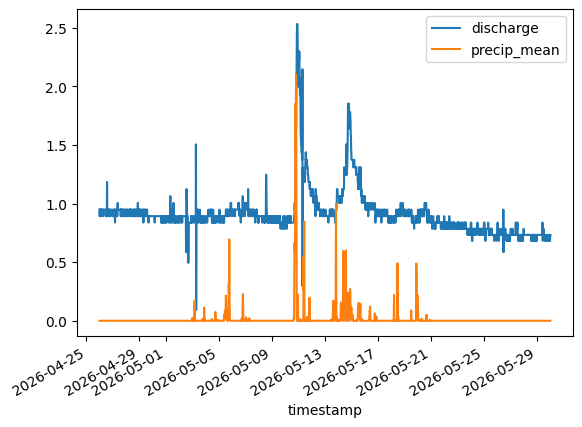

In [111]:
from jobs.discharge.preprocessing.filtering import hampel_filter
df_conc = pd.concat(
    [
        df_discharge,
        # hampel_filter(df_discharge, window=11, n_sigmas=1),
        # hampel_filter(df_discharge, window=4*4, n_sigmas=1),
        # hampel_filter(
        #     df_discharge, window=5, n_sigmas=1
        #     ).ewm(
        #         span=5,
        #         adjust=True
        #     ).mean(),
        
        df_precip_observation
    ],
    axis=1,
    join="inner"
    )

df_conc = df_conc.dropna(axis="index")

df_conc.plot()

In [112]:
df_conc_features = create_training_features(df_conc, horizon=inference_steps)
# print(len(df_conc_features))
print("Num features: ", len(df_conc_features.columns))
# df_conc_features

dataset = TimeSeriesDataset(df_conc_features)

train_dataset, val_dataset, test_dataset = (
    dataset.create_datasets()
)

Num features:  87
Train size: 2249
Val size: 642
Test size: 322


In [144]:
from jobs.inference.ingest_inference import load_discharge_data, load_precip_observation_data, merge_data, create_inference_features, run_inference, build_forecast_dataframe

In [145]:
discharge = load_discharge_data(days=7)
precip_observation = load_precip_observation_data(days=7)

dfs = [discharge, precip_observation]

merged = merge_data(dfs=dfs)

features = create_inference_features(df=merged)

inference = run_inference(df=features)

In [149]:
build_forecast_dataframe(
    delta_discharge=inference,
    features=features, 
    freq="15min"
)

,predicted
timestamp,
2026-05-30 14:45:00,0.743739


In [151]:
load_inference_data()

,predicted
timestamp,
2026-05-16 16:15:00,1.120645
2026-05-16 16:45:00,1.120645
2026-05-16 21:15:00,1.120645
2026-05-16 21:45:00,1.120645
2026-05-16 22:15:00,1.118491
...,...
2026-05-30 12:45:00,0.869272
2026-05-30 13:15:00,0.965064
2026-05-30 13:45:00,0.965064


In [113]:
# Fit model
model.fit(
    train_dataset[0], 
    train_dataset[1],
    eval_set=[(val_dataset[0], val_dataset[1])]
)

[0]	validation_0-rmse:0.03481
[1]	validation_0-rmse:0.03481
[2]	validation_0-rmse:0.03480
[3]	validation_0-rmse:0.03480
[4]	validation_0-rmse:0.03479
[5]	validation_0-rmse:0.03479
[6]	validation_0-rmse:0.03478
[7]	validation_0-rmse:0.03478
[8]	validation_0-rmse:0.03477
[9]	validation_0-rmse:0.03477
[10]	validation_0-rmse:0.03477
[11]	validation_0-rmse:0.03476
[12]	validation_0-rmse:0.03476
[13]	validation_0-rmse:0.03476
[14]	validation_0-rmse:0.03476
[15]	validation_0-rmse:0.03476
[16]	validation_0-rmse:0.03476
[17]	validation_0-rmse:0.03476
[18]	validation_0-rmse:0.03476
[19]	validation_0-rmse:0.03476
[20]	validation_0-rmse:0.03476
[21]	validation_0-rmse:0.03476
[22]	validation_0-rmse:0.03476
[23]	validation_0-rmse:0.03476
[24]	validation_0-rmse:0.03476
[25]	validation_0-rmse:0.03476
[26]	validation_0-rmse:0.03477
[27]	validation_0-rmse:0.03477
[28]	validation_0-rmse:0.03477
[29]	validation_0-rmse:0.03477
[30]	validation_0-rmse:0.03478
[31]	validation_0-rmse:0.03478
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,[-4.7592377e-05]
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,150
,enable_categorical,False
,eval_metric,None


In [114]:
# Save model
save_dir = Path("models")
# model_name = "xgb_model_discharge_precip.json"
model_name = "xgb_model_discharge_precip_hampel_ewm.json"
save_path = save_dir / model_name

model.save_model(save_path)
print(f"Saved model '{model_name}' to {save_path}")


Saved model 'xgb_model_discharge_precip_hampel_ewm.json' to models\xgb_model_discharge_precip_hampel_ewm.json


In [115]:
from model.evaluation import evaluate_model

# Eval dir
eval_dir = Path("model/evaluation")
model_dir = Path("models/xgb_model_discharge_precip_hampel_ewm.json")


# Predict & evaluate
model.load_model(model_dir)


# y_pred = model.predict(train_dataset[0])
# y_pred = model.predict(test_dataset[0])
# y_pred = model.predict(val_dataset[0])

delta_q = model.predict(test_dataset[0])
current_q = test_dataset[0]["discharge"]
predicted_discharge = current_q + delta_q


# evaluate_model(
#     model=model,
#     # dataset=test_dataset, 
#     # dataset=val_dataset, 
#     dataset=train_dataset,
#     pred=predicted_discharge,
#     # save_dir=eval_dir,
#     )

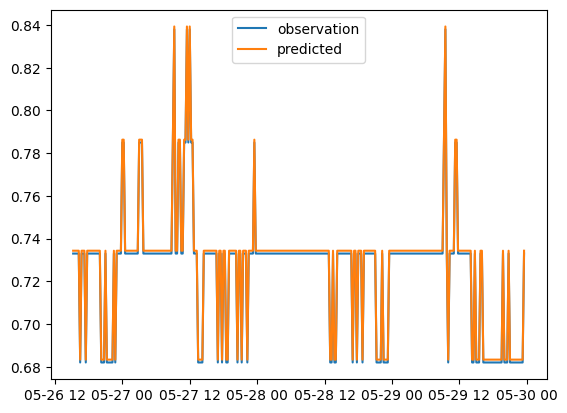

In [119]:
current_q = test_dataset[0]["discharge"]
# predicted_discharge = current_q
predicted_discharge = current_q + delta_q

plt.plot(current_q, label = "observation")
plt.plot(predicted_discharge, label="predicted")
plt.legend()

In [120]:
importance = pd.DataFrame(
    {
        "feature": train_dataset[0].columns,
        "importance": model.feature_importances_,
    }
).sort_values(
    "importance",
    ascending=False,
)

importance
# print(importance)

,feature,importance
58,precip_mean_delay_8_sum_8,0.253494
21,precip_mean_48,0.129627
0,discharge,0.074498
47,precip_mean_delay_4_sum_2,0.046618
6,discharge_1,0.045144
...,...,...
81,precip_mean_delay_48_sum_4,0.000000
82,precip_mean_delay_48_sum_8,0.000000
83,precip_mean_delay_48_sum_12,0.000000
84,precip_mean_delay_48_sum_24,0.000000


In [11]:
from jobs.inference.ingest_inference import create_inference_features, run_inference, merge_data
from database.queries import load_inference_data

In [89]:
test = load_inference_data()
test.tail(1)

,predicted
timestamp,
2026-05-30 13:45:00,0.965064


In [27]:
discharge = load_discharge_data(days=7)
precip_observation = load_precip_observation_data(days=7)

dfs = [discharge, precip_observation]

merged = merge_data(dfs=dfs)

features = create_inference_features(df=merged)

inference = run_inference(df=features)

In [26]:
discharge = load_discharge_data()
discharge.tail(2)

,discharge
timestamp,
2026-05-26 22:00:00,0.682
2026-05-26 22:15:00,0.682


In [22]:
merged.tail(1)

,discharge,precip_mean
timestamp,,
2026-05-26 22:15:00,0.682,NaN


In [17]:
inference = build_forecast_dataframe(
    preds=inference,
    history_index=features.index,
    freq="15min"
)

write_to_db(inference)

2026-05-27 00:16:28,849 | ingest_inference.py | INFO | [INFERENCE] Inserted 1 rows.


In [36]:
import requests
import pandas as pd
import streamlit as st
from streamlit_autorefresh import st_autorefresh
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from dashboard.prepare_data import prepare_data
from configs.dashboard_config import API_URL, REFRESH_INTERVAL


# auto refresh every minute
st_autorefresh(
    interval=REFRESH_INTERVAL,
    key="dashboard_refresh",
)


# --- GET request ---
try:
    response = requests.get(API_URL, timeout=10)
    response.raise_for_status()

    data = response.json()

except requests.RequestException as e:
    st.error(f"API unavailable: {e}")
    st.stop()


# --- Prepare data for plotting ---
df_discharge = pd.DataFrame(data["discharge"])
df_inference = pd.DataFrame(data["inference"])
df_precip_obs = pd.DataFrame(data["precip_obs"])
df_precip_pred = pd.DataFrame(data["precip_pred"])


2026-05-27 00:26:08.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:26:08.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:26:08.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:26:08.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:26:08.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [37]:
df_discharge

,timestamp,discharge
0,2026-05-13T00:30:00,0.893
1,2026-05-13T00:45:00,0.949
2,2026-05-13T01:00:00,0.949
3,2026-05-13T01:15:00,0.893
4,2026-05-13T01:30:00,0.893
...,...,...
1334,2026-05-26T22:00:00,0.682
1335,2026-05-26T22:15:00,0.682
1336,2026-05-26T22:30:00,0.733
1337,2026-05-26T22:45:00,0.682


In [32]:
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data

In [48]:
df_discharge = load_discharge_data()
df_discharge.index.max()

Timestamp('2026-05-26 22:30:00')

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/abfluss_queich")

In [3]:
import requests
import pandas as pd
import streamlit as st
from streamlit_autorefresh import st_autorefresh
import plotly.graph_objects as go

from configs.dashboard_config import REFRESH_INTERVAL, DEFAULT_DASHBOARD_DAYS

from dashboard.api import fetch_dashboard_data
from dashboard.prepare_data import prepare_datasets
from dashboard.plotting.layout import create_dashboard_layout


st.set_page_config(layout="wide")

st_autorefresh(
    interval=REFRESH_INTERVAL,
    key="dashboard_refresh",
)


data = fetch_dashboard_data()

2026-05-27 18:48:17.129 No runtime found, using MemoryCacheStorageManager
2026-05-27 18:48:17.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 18:48:17.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 18:48:17.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 18:48:17.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 18:48:17.218 
  command:

    streamlit run C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-27 18:48:17.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 18:48:17.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 

In [19]:
from database.queries import load_inference_data
from dashboard.prepare_data import prepare_datasets, prepare_forecast_df
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data

In [20]:
load_precip_forecast_data()

,precip_mean
timestamp,
2026-05-17 00:15:00,0.0
2026-05-17 00:30:00,0.0
2026-05-17 00:45:00,0.0
2026-05-17 01:00:00,0.0
2026-05-17 01:15:00,0.0
...,...
2026-05-27 17:45:00,0.0
2026-05-27 18:00:00,0.0
2026-05-27 18:15:00,0.0


In [9]:
discharge = pd.DataFrame(data["discharge"])
inference = pd.DataFrame(data["inference"])
precip_obs = pd.DataFrame(data["precip_obs"])
precip_pred = pd.DataFrame(data["precip_pred"])

print(precip_pred.columns)

Index(['timestamp', 'precip_mean'], dtype='object')


In [16]:
datasets = prepare_datasets(data=data)

In [17]:
datasets["precip_pred"]

,precip_mean
timestamp,
2026-05-17 00:15:00,0.0
2026-05-17 00:30:00,0.0
2026-05-17 00:45:00,0.0
2026-05-17 01:00:00,0.0
2026-05-17 01:15:00,0.0
...,...
2026-05-27 17:45:00,0.0
2026-05-27 18:00:00,0.0
2026-05-27 18:15:00,0.0
